## Import packages


In [1]:
%pip install -q scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [3]:
import math
import os
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings("ignore")

## TPU or GPU detection


In [4]:

try:
    # Create a TPUClusterResolver instance
    resolver = tf.distribute.cluster_resolver.TPUClusterResolver(tpu="local")
    # Connect to the TPU cluster
    tf.config.experimental_connect_to_cluster(resolver)
    # Initialize the TPU system
    tf.tpu.experimental.initialize_tpu_system(resolver)
    # Create a TPUStrategy
    strategy = tf.distribute.TPUStrategy(resolver)
    print("Running on TPU")
except tf.errors.NotFoundError:
    print("Not running on TPU")
    # If TPU is not available, fall back to MirroredStrategy
    strategy = tf.distribute.MirroredStrategy()

print("REPLICAS:", strategy.num_replicas_in_sync)


Not running on TPU
REPLICAS: 2


## Configuration


In [7]:
AUTOTUNE = tf.data.AUTOTUNE

NUM_CLASS = 3
CLASSES = ['COVID-19', 'Non-COVID', 'Normal']

IMAGE_SIZE = [224, 224]
LR = 1e-5
EPOCHS = 100
BATCH_SIZE = 16 * strategy.num_replicas_in_sync

#Infection Segmentation Data
#TRAIN_PATH = '/kaggle/input/covidqu/Infection Segmentation Data/Infection Segmentation Data/Train/'
#TEST_PATH = '/kaggle/input/covidqu/Infection Segmentation Data/Infection Segmentation Data/Test'
#VAL_PATH = '/kaggle/input/covidqu/Infection Segmentation Data/Infection Segmentation Data/Val'

#Lung Segmentation Data
TRAIN_PATH = '/kaggle/input/covidqu/Lung Segmentation Data/Lung Segmentation Data/Train/'
TEST_PATH = '/kaggle/input/covidqu/Lung Segmentation Data/Lung Segmentation Data/Test'
VAL_PATH = '/kaggle/input/covidqu/Lung Segmentation Data/Lung Segmentation Data/Val'

## Utilities


In [6]:
def batch_to_numpy_images_and_labels(data):
    images, labels = data
    numpy_images = images.numpy()
    numpy_labels = labels.numpy()
    return numpy_images, np.argmax(numpy_labels, axis=1)


def title_from_label_and_target(label, correct_label):
    if correct_label is None:
        return CLASSES[label], True
    correct = (label == correct_label)
    return "{} [{}{}{}]".format(CLASSES[label], 'OK' if correct else 'NO', u"\u2192" if not correct else '',
                                CLASSES[correct_label] if not correct else ''), correct


def display_one(image, title, subplot, red=False, titlesize=16):
    plt.subplot(*subplot)
    plt.axis('off')
    plt.imshow(image)
    if len(title) > 0:
        plt.title(title, fontsize=int(titlesize) if not red else int(titlesize/1.2),
                  color='red' if red else 'black', fontdict={'verticalalignment': 'center'}, pad=int(titlesize/1.5))
    return (subplot[0], subplot[1], subplot[2]+1)


def display_batch(databatch, predictions=None):
    """This will work with:
    display_batch_of_images(images)
    display_batch_of_images(images, predictions)
    display_batch_of_images((images, labels))
    display_batch_of_images((images, labels), predictions)
    """
    # data
    images, labels = batch_to_numpy_images_and_labels(databatch)

    # auto-squaring: this will drop data that does not fit into square or square-ish rectangle
    rows = int(math.sqrt(len(images)))
    cols = len(images)//rows

    # size and spacing
    FIGSIZE = 13.0
    SPACING = 0.1
    subplot = (rows, cols, 1)
    if rows < cols:
        plt.figure(figsize=(FIGSIZE, FIGSIZE/cols*rows))
    else:
        plt.figure(figsize=(FIGSIZE/rows*cols, FIGSIZE))

    # display
    for i, (image, label) in enumerate(zip(images[:rows*cols], labels[:rows*cols])):
        title = '' if label is None else CLASSES[label]
        correct = True
        if predictions is not None:
            title, correct = title_from_label_and_target(predictions[i], label)
        dynamic_titlesize = FIGSIZE*SPACING/max(rows, cols)*40+3
        # magic formula tested to work from 1x1 to 10x10 images
        subplot = display_one(image, title, subplot,
                              not correct, titlesize=dynamic_titlesize)

    # layout
    plt.tight_layout()
    if label is None and predictions is None:
        plt.subplots_adjust(wspace=0, hspace=0)
    else:
        plt.subplots_adjust(wspace=SPACING, hspace=SPACING)
    plt.show()


In [8]:
def display_history(history):
    plt.figure()
    fig, ax = plt.subplots(1, 2, figsize=(12, 3))
    ax[0].plot(history.history['loss'], color='b', label="training_loss")
    ax[0].plot(history.history['val_loss'], color='r',
               label="validation_loss", axes=ax[0])
    legend = ax[0].legend(loc='best', shadow=True)

    ax[1].plot(history.history['accuracy'],
               color='b', label="training_accuracy")
    ax[1].plot(history.history['val_accuracy'],
               color='r', label="validation_accuracy")
    legend = ax[1].legend(loc='best', shadow=True)
    plt.tight_layout()
    plt.show()


def display_confusion_matrix(
        cm, classes,
        normalize=False,
        title='Confusion matrix',
        cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    plt.figure()
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()


## Dataset


In [9]:
def create_dataframe(data_dir):
    filenames, labels = [], []
    for fold in os.listdir(data_dir):
        path = os.path.join(data_dir, fold, 'images')
        filelist = [os.path.join(path, filename)
                    for filename in os.listdir(path)]
        filenames.extend(filelist)
        labels.extend([fold] * len(filelist))
    return pd.DataFrame({
        'filename': filenames,
        'label': labels
    })


train_df = create_dataframe(TRAIN_PATH)
val_df = create_dataframe(VAL_PATH)
test_df = create_dataframe(TEST_PATH)


In [10]:
NUM_TRAINING_IMAGES = len(train_df.index)
NUM_VALIDATION_IMAGES = len(val_df)
NUM_TEST_IMAGES = len(test_df)

STEPS_PER_EPOCH = NUM_TRAINING_IMAGES // BATCH_SIZE
VALIDATION_STEPS = -(- NUM_VALIDATION_IMAGES // BATCH_SIZE)
TEST_STEPS = -(-NUM_TEST_IMAGES // BATCH_SIZE)

print("Training images:", NUM_TRAINING_IMAGES)
train_label_counts = train_df['label'].value_counts().rename(
    index=dict(enumerate(CLASSES)))
print(", ".join([f"{label}: {count}" for label,
      count in train_label_counts.items()]))
print()

print("Validation images:", NUM_VALIDATION_IMAGES)
val_label_counts = val_df['label'].value_counts().rename(
    index=dict(enumerate(CLASSES)))
print(", ".join([f"{label}: {count}" for label,
      count in val_label_counts.items()]))
print()

print("Test images:", NUM_TEST_IMAGES)
test_label_counts = test_df['label'].value_counts().rename(
    index=dict(enumerate(CLASSES)))
print(", ".join([f"{label}: {count}" for label,
      count in test_label_counts.items()]))


Training images: 21715
COVID-19: 7658, Non-COVID: 7208, Normal: 6849

Validation images: 5417
COVID-19: 1903, Non-COVID: 1802, Normal: 1712

Test images: 6788
COVID-19: 2395, Non-COVID: 2253, Normal: 2140


#### Data augmentation


In [11]:
def data_augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.1)
    image = tf.image.random_contrast(image, 0.8, 1.2)

    return image, label


In [ ]:
# data_augment = tf.keras.Sequential([
#     tf.keras.layers.experimental.preprocessing.RandomFlip("horizontal"),
#     tf.keras.layers.experimental.preprocessing.RandomRotation(0.2),
#     tf.keras.layers.experimental.preprocessing.RandomZoom(0.2),
#     tf.keras.layers.experimental.preprocessing.RandomContrast(0.1)
# ])


In [12]:
def get_label(label):
    onehot = label == CLASSES
    return tf.cast(onehot, tf.int32)


def decode_image(path):
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.convert_image_dtype(image, tf.float32)
    image = tf.image.resize(image, IMAGE_SIZE)
    return image


def preprocess_path(path, label):
    return decode_image(path), get_label(label)


In [13]:
def load_dataset(df=pd.DataFrame(), ordered=False):
    ignore_order = tf.data.Options()
    if not ordered:
        ignore_order.experimental_deterministic = False  # disable order, increase speed
    dataset = tf.data.Dataset.from_tensor_slices(
        (df['filename'].values, df['label'].values))
    # uses data as soon as it streams in, rather than in its original order
    dataset = dataset.with_options(ignore_order)
    dataset = dataset.map(preprocess_path, num_parallel_calls=AUTOTUNE)
    return dataset


In [14]:
def get_train_dataset(augment=False):
    dataset = load_dataset(train_df)
    if(augment):
        dataset = dataset.map(data_augment, num_parallel_calls=AUTOTUNE)
    dataset = dataset.repeat()
    dataset = dataset.shuffle(BATCH_SIZE * 100)
    dataset = dataset.batch(BATCH_SIZE)
#     if (augment):
#         dataset = dataset.map(lambda x, y: (data_augment(x), y))
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


In [15]:
def get_validation_dataset(ordered=False):
    dataset = load_dataset(val_df, ordered=ordered)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.cache()
    dataset = dataset.prefetch(AUTOTUNE)
    return dataset


In [16]:
def get_test_dataset(ordered=False):
    dataset = load_dataset(test_df, ordered=ordered)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)
    return dataset


## Dataset visualizations


In [17]:
training_dataset = get_train_dataset()
training_dataset = training_dataset.unbatch().batch(16)
train_batch = iter(training_dataset)


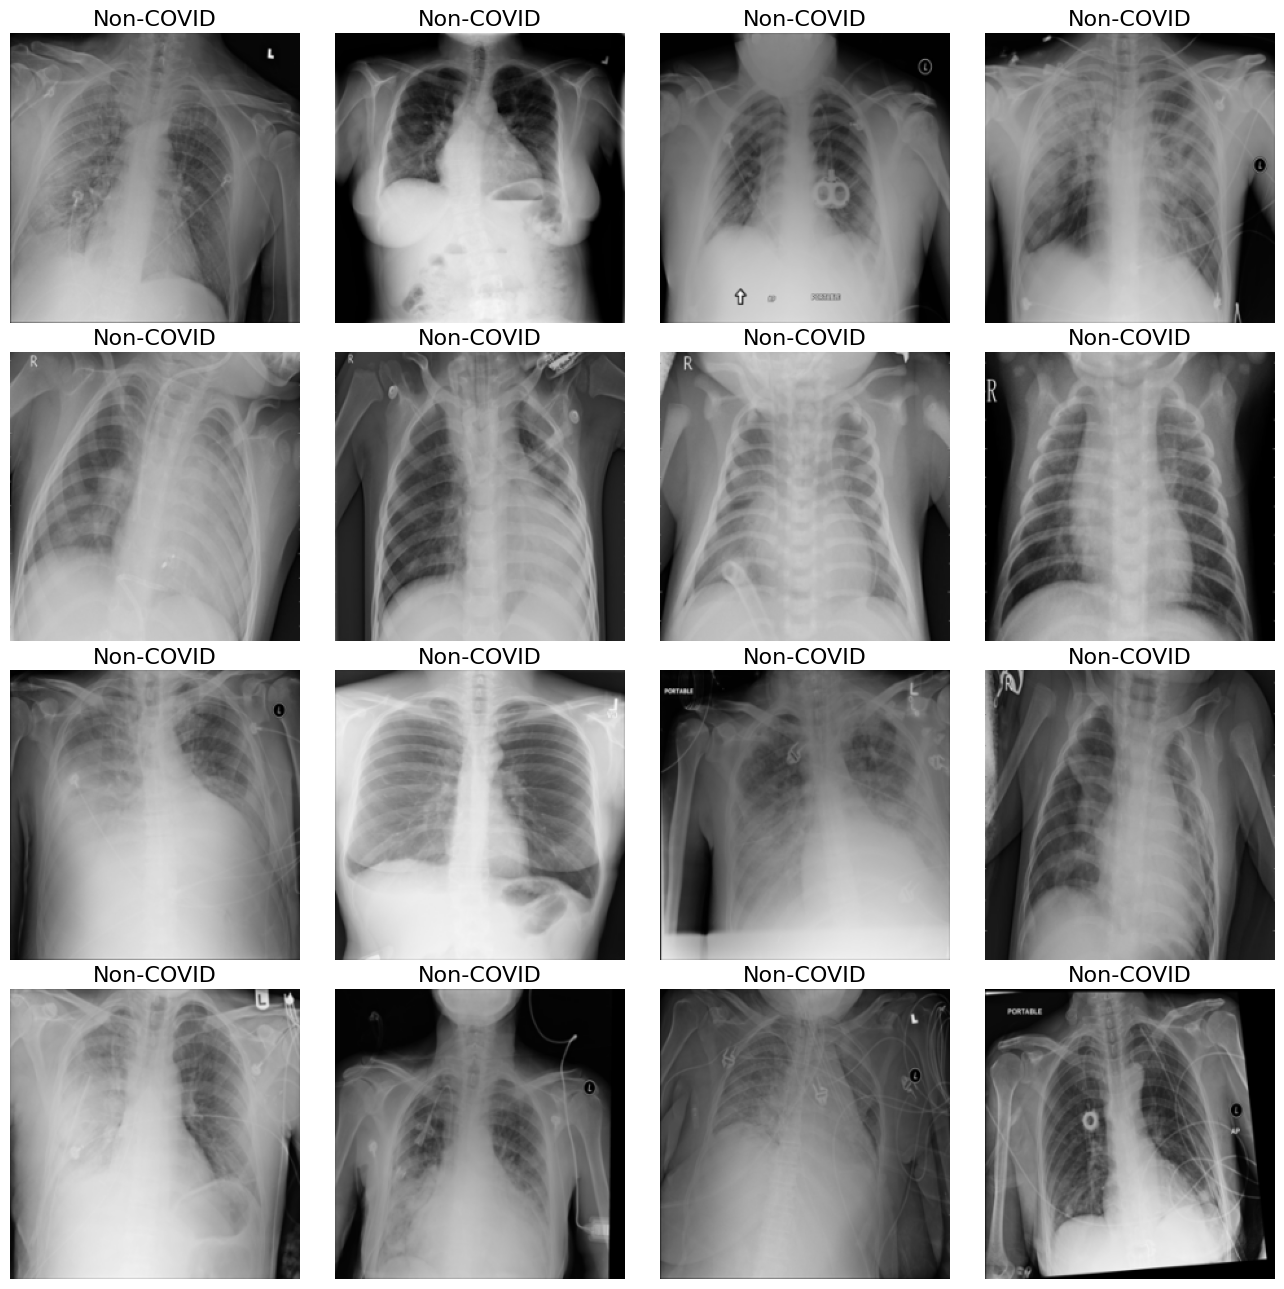

In [18]:
# run this cell again for another randomized set of training images
display_batch(next(train_batch))


In [19]:
print("Training data shapes:")
for image, label in get_train_dataset().take(1):
    print(image.numpy().shape, label.numpy().shape)

print("Validation data shapes:")
for image, label in get_train_dataset().take(1):
    print(image.numpy().shape, label.numpy().shape)

print("Test data shapes:")
for image, label in get_test_dataset().take(1):
    print(image.numpy().shape, label.numpy().shape)


Training data shapes:
(32, 224, 224, 3) (32, 3)
Validation data shapes:
(32, 224, 224, 3) (32, 3)
Test data shapes:
(32, 224, 224, 3) (32, 3)


## Model


In [20]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_vgg16.h5',
    monitor='val_loss',
    verbose=1,
    save_best_only=True,
    mode='min'
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-7,
)


In [21]:
with strategy.scope():
    baseModel = tf.keras.applications.VGG16(
        include_top=False,
        weights='imagenet',
        input_shape=(224, 224, 3),
    )


    model = tf.keras.Sequential([
        baseModel,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(NUM_CLASS, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )


58889256/58889256 [==============================] - 0s 0us/step


In [22]:
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 global_average_pooling2d (G  (None, 512)              0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 3)                 1539      
                                                                 
Total params: 14,716,227
Trainable params: 14,716,227
Non-trainable params: 0
_________________________________________________________________


## Training


In [ ]:
history = model.fit(
    get_train_dataset(augment=True),
    steps_per_epoch=STEPS_PER_EPOCH,
    epochs=EPOCHS,
    validation_data=get_validation_dataset(),
    validation_steps=VALIDATION_STEPS,
    callbacks=[checkpoint, reduce_lr]
)

model.save('vgg16.h5')


In [ ]:
display_history(history)


## Evaluate


In [23]:
#model = tf.keras.models.load_model('vgg16.h5')
model_path = '/kaggle/input/vgg16-tpu/best_vgg16.h5'
model = tf.keras.models.load_model(model_path)


In [24]:
val_dataset = get_validation_dataset(ordered=True)
results = model.evaluate(
    val_dataset, batch_size=BATCH_SIZE, steps=VALIDATION_STEPS)
print('Test loss: {:4f}'.format(results[0]))
print('Test accuracy: {:4f}'.format(results[1]))


170/170 [==============================] - 39s 137ms/step - loss: 0.1825 - accuracy: 0.9308
Test loss: 0.182455
Test accuracy: 0.930773


170/170 [==============================] - 20s 117ms/step
              precision    recall  f1-score   support

    COVID-19       0.98      0.97      0.98      1903
   Non-COVID       0.91      0.91      0.91      1802
      Normal       0.90      0.91      0.90      1712

    accuracy                           0.93      5417
   macro avg       0.93      0.93      0.93      5417
weighted avg       0.93      0.93      0.93      5417



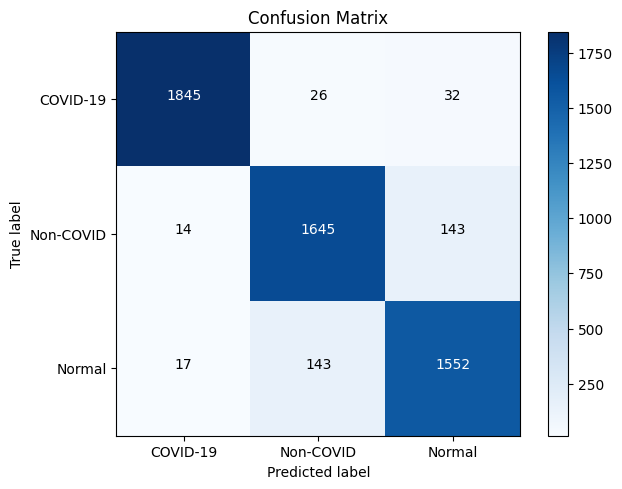

In [25]:
images_ds = val_dataset.map(lambda image, label: image)
labels_ds = val_dataset.map(lambda image, label: label).unbatch()
correct_labels = next(iter(labels_ds.batch(NUM_VALIDATION_IMAGES))).numpy()

pred = model.predict(val_dataset, steps=VALIDATION_STEPS)

y_true = np.argmax(correct_labels, axis=-1)
y_pred = np.argmax(pred, axis=-1)

print(classification_report(y_true, y_pred, target_names=CLASSES))

cm = confusion_matrix(y_true, y_pred)
display_confusion_matrix(cm=cm, classes=CLASSES, title='Confusion Matrix')


## Testing


In [26]:
dataset = get_test_dataset()
#dataset = dataset.unbatch().batch(20)
batch = iter(dataset)


1/1 [==============================] - 0s 188ms/step


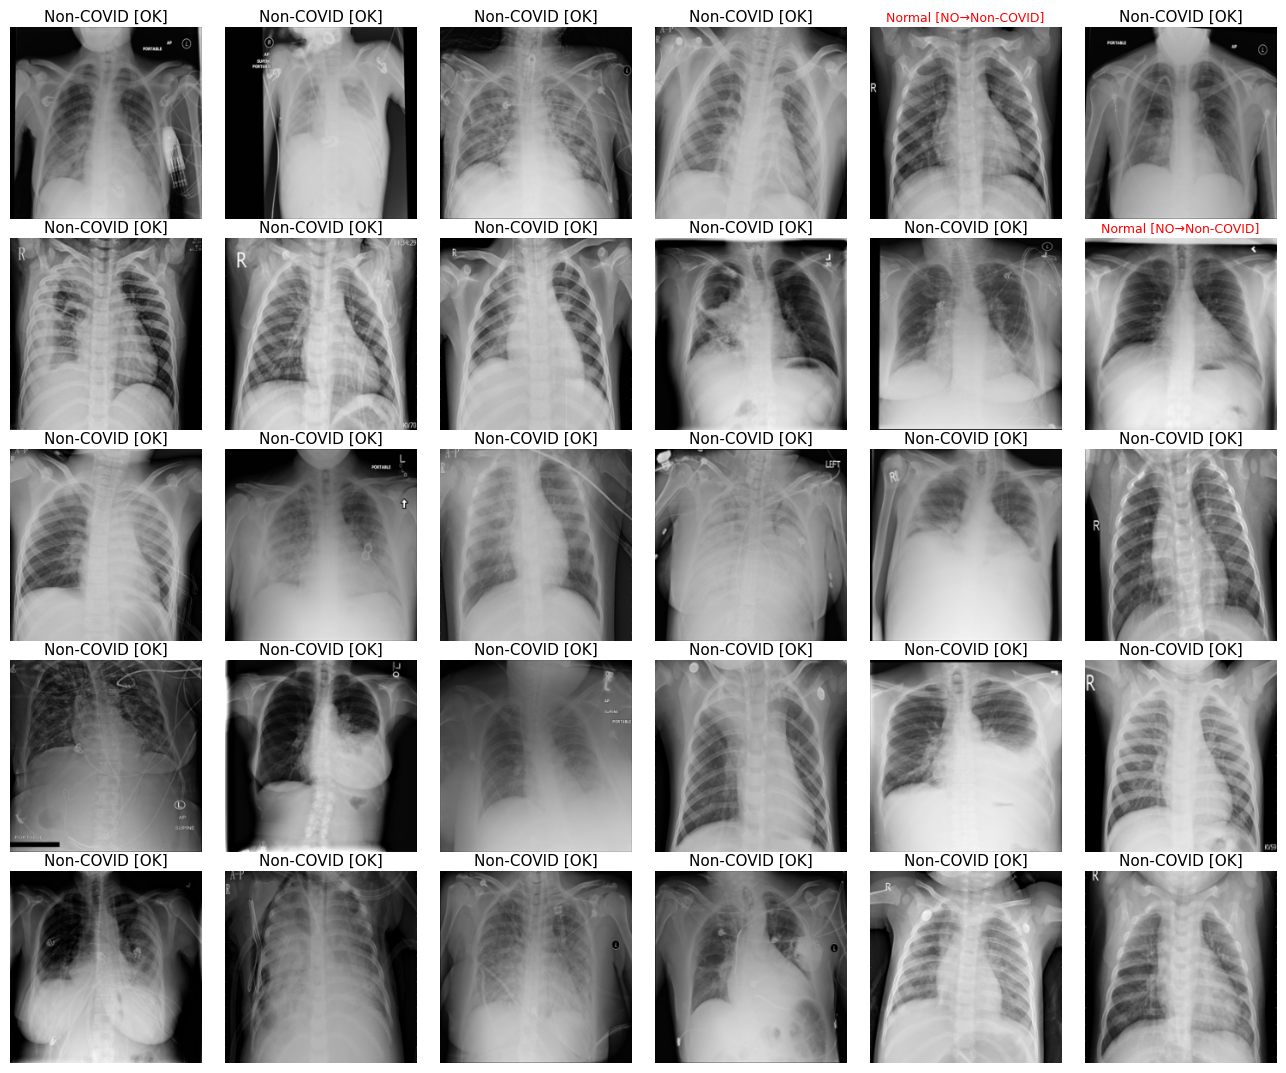

<tf.Tensor: shape=(32, 3), dtype=int32, numpy=
array([[0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0]], dtype=int32)>

In [27]:
# run this cell again for next set of images
images, labels = next(batch)
probabilities = model.predict(images)
predictions = np.argmax(probabilities, axis=-1)
display_batch((images, labels), predictions)
labels


In [28]:
from scipy.spatial.qhull import QhullError
from scipy import spatial
spatial.QhullError = QhullError

In [29]:
from skimage.segmentation import mark_boundaries

  0%|          | 0/1000 [00:00<?, ?it/s]

4/4 [==============================] - 0s 110ms/step


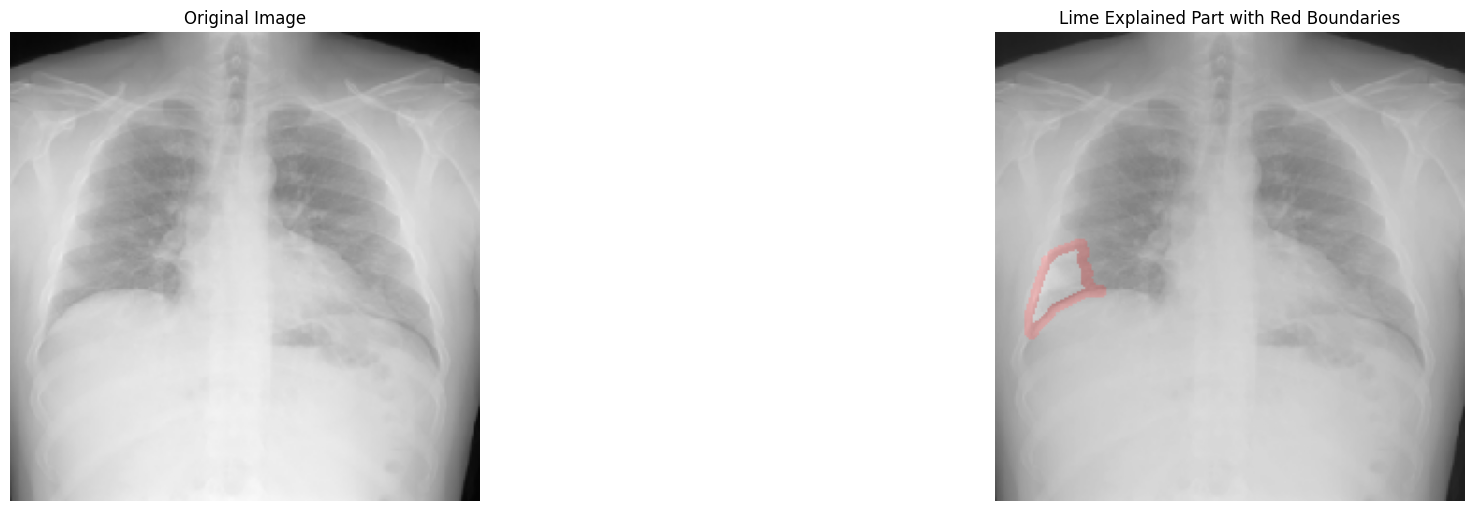

1/1 [==============================] - 0s 26ms/step
The model predicts the image as: COVID-19 with confidence: 1.00
[[0. 0. 1.]]


In [51]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries, slic
from PIL import Image

# Load your trained model
model_path = '/kaggle/input/vgg16-tpu/best_vgg16.h5'
model = tf.keras.models.load_model(model_path)

# Prepare data for Lime analysis
explainer = lime_image.LimeImageExplainer()

# Choose the directory containing the images
image_directory = '/kaggle/input/covidqu/Lung Segmentation Data/Lung Segmentation Data/Test/COVID-19/images'
lung_mask_directory = '/kaggle/input/covidqu/Lung Segmentation Data/Lung Segmentation Data/Test/COVID-19/lung masks'

# Choose the specific filename for which you want an explanation
filename = 'covid_10.png'

# Load the image
image_path = os.path.join(image_directory, filename)
image_np = tf.keras.preprocessing.image.load_img(image_path, target_size=(224, 224))
image_np = tf.keras.preprocessing.image.img_to_array(image_np)
image_np = np.expand_dims(image_np, axis=0)  # Add batch dimension

# Load the lung mask
lung_mask_path = os.path.join(lung_mask_directory, filename)
lung_mask = np.array(Image.open(lung_mask_path).convert('L'))  # Convert to grayscale

# Add a channel dimension to the lung mask
lung_mask = np.expand_dims(lung_mask, axis=-1)

# Resize the lung mask to match the dimensions of the original image
lung_mask_resized = tf.image.resize(lung_mask, (224, 224))

# Apply lung mask to the original image
image_with_lungs = image_np[0] * lung_mask_resized

# Convert the image to a NumPy array
image_with_lungs_np = image_with_lungs.numpy()

# Use the image with lung mask for Lime explanation
explanation = explainer.explain_instance(
    image_with_lungs_np,             # Image with lung mask
    model.predict,                   # Model prediction function
    top_labels=1,                    # Number of top labels to consider
    hide_color=None,                 # Do not hide occluded parts of the image
    num_samples=1000,                # Number of random samples to generate
    batch_size=100,                  # Batch size for generating samples
    random_seed=22,                  # Random seed for reproducibility
    segmentation_fn= slic,            # Custom segmentation function
    distance_metric='euclidean',     # Distance metric for perturbation
    model_regressor=None             # Custom model regressor if needed
)

# Get the Lime-explained part and mask
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, num_features=1, hide_rest=True)

# Resize the Lime-explained part to match the original image size
temp_resized = tf.image.resize(temp, (224, 224))

# Apply lung mask to Lime-explained part
temp_masked = temp_resized * lung_mask_resized

# Convert temp_masked to a NumPy array
temp_masked_np = temp_masked.numpy()

# Set the Lime-explained part outside the lung mask to zero
temp_masked_np[np.squeeze(lung_mask_resized.numpy()) == 0] = 0

# Plot the original image
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(image_np[0] / 255.0)  # Assuming image values are scaled between 0 and 255
plt.title('Original Image')
plt.axis('off')

# Plot the Lime-explained part with red boundaries overlaid on the original image
plt.subplot(1, 3, 3)
lime_boundaries = mark_boundaries(temp_masked_np / 2 + 0.5, mask, color=(1, 0, 0), outline_color=(1, 0, 0), mode='thick')
plt.imshow(image_np[0] / 255.0)  # Original image as background
plt.imshow(lime_boundaries, alpha=0.2)  # Overlay Lime-explained part with transparency
plt.title('Lime Explained Part with Red Boundaries')
plt.axis('off')

plt.tight_layout(w_pad=0.5)  # Adjust the width space between subplots
plt.show()

# Reshape the image to match the expected input shape of the model
image_with_lungs_np = np.expand_dims(image_with_lungs_np, axis=0)

# Use the image with lung mask for prediction
prediction = model.predict(image_with_lungs_np)
#Decode the prediction
class_labels = ["Normal", "Non-COVID Infection", "COVID-19"]  # Assuming three classes
predicted_class_index = np.argmax(prediction)
predicted_class = class_labels[predicted_class_index]
confidence = prediction[0,np.argmax(prediction) ]

# Print the prediction
print(f"The model predicts the image as: {predicted_class} with confidence: {confidence:.2f}")
print(prediction)



  0%|          | 0/1000 [00:00<?, ?it/s]

4/4 [==============================] - 0s 114ms/step


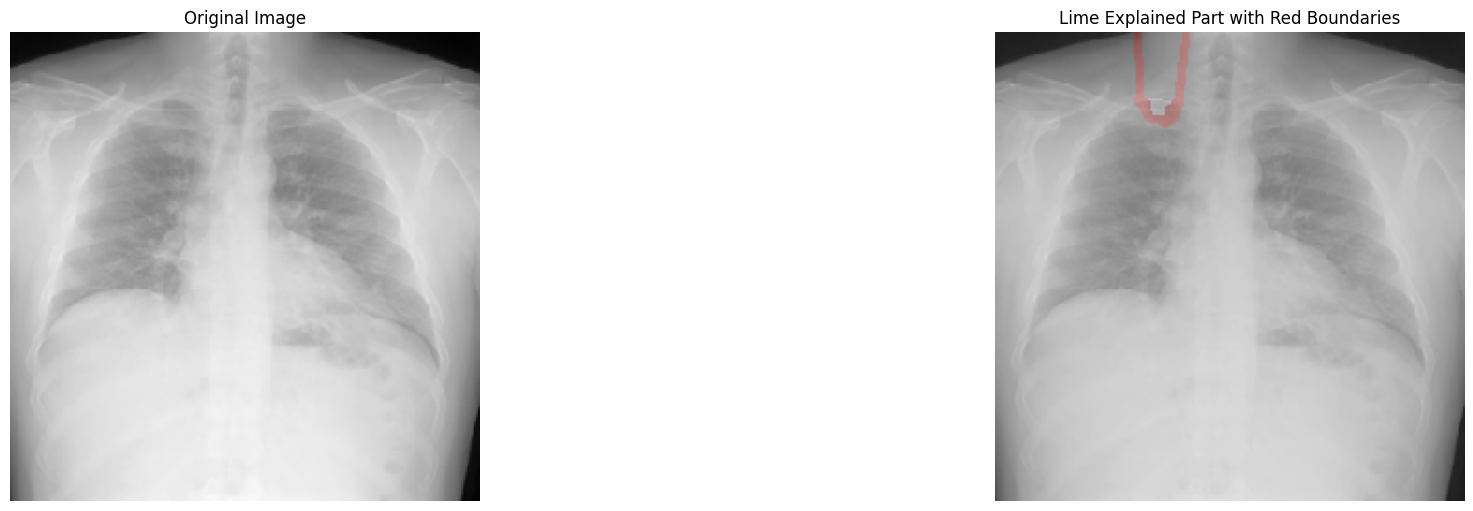

1/1 [==============================] - 0s 31ms/step
The model predicts the perturbed image as: COVID-19 with confidence: 1.00
[[0. 0. 1.]]


In [52]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries, slic
from PIL import Image

# Load your trained model
model_path = '/kaggle/input/vgg16-tpu/best_vgg16.h5'
model = tf.keras.models.load_model(model_path)

# Prepare data for Lime analysis
explainer = lime_image.LimeImageExplainer()

# Choose the directory containing the images
image_directory = '/kaggle/input/covidqu/Lung Segmentation Data/Lung Segmentation Data/Test/COVID-19/images'
lung_mask_directory = '/kaggle/input/covidqu/Lung Segmentation Data/Lung Segmentation Data/Test/COVID-19/lung masks'

# Choose the specific filename for which you want an explanation
filename = 'covid_10.png'

# Load the image
image_path = os.path.join(image_directory, filename)
image_np = tf.keras.preprocessing.image.load_img(image_path, target_size=(224, 224))
image_np = tf.keras.preprocessing.image.img_to_array(image_np)
image_np = np.expand_dims(image_np, axis=0)  # Add batch dimension

# Load the lung mask
lung_mask_path = os.path.join(lung_mask_directory, filename)
lung_mask = np.array(Image.open(lung_mask_path).convert('L'))  # Convert to grayscale

# Add a channel dimension to the lung mask
lung_mask = np.expand_dims(lung_mask, axis=-1)

# Resize the lung mask to match the dimensions of the original image
lung_mask_resized = tf.image.resize(lung_mask, (224, 224))

# Apply lung mask to the original image
image_with_lungs = image_np[0] * lung_mask_resized

# Convert the image to a NumPy array
image_with_lungs_np = image_with_lungs.numpy()

# Define perturbation magnitude
epsilon = 0.05

# Generate perturbation
perturbation = epsilon * np.random.normal(size=image_with_lungs_np.shape)

# Perturb the original image
perturbed_image_with_lungs = image_with_lungs_np + perturbation

# Use the perturbed image with lung mask for Lime explanation
explanation = explainer.explain_instance(
    perturbed_image_with_lungs,      # Perturbed image with lung mask
    model.predict,                   # Model prediction function
    top_labels=1,                    # Number of top labels to consider
    hide_color=None,                 # Do not hide occluded parts of the image
    num_samples=1000,                # Number of random samples to generate
    batch_size=100,                  # Batch size for generating samples
    random_seed=22,                  # Random seed for reproducibility
    segmentation_fn=slic,            # Custom segmentation function
    distance_metric='euclidean',     # Distance metric for perturbation
    model_regressor=None             # Custom model regressor if needed
)

# Get the Lime-explained part and mask for perturbed image
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, num_features=1, hide_rest=True)

# Resize the Lime-explained part to match the original image size
temp_resized = tf.image.resize(temp, (224, 224))

# Apply lung mask to Lime-explained part
temp_masked = temp_resized * lung_mask_resized

# Convert temp_masked to a NumPy array
temp_masked_np = temp_masked.numpy()

# Set the Lime-explained part outside the lung mask to zero
temp_masked_np[np.squeeze(lung_mask_resized.numpy()) == 0] = 0

# Plot the original image
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(image_np[0] / 255.0)  # Assuming image values are scaled between 0 and 255
plt.title('Original Image')
plt.axis('off')

# Plot the Lime-explained part with red boundaries overlaid on the original image
plt.subplot(1, 3, 3)
lime_boundaries = mark_boundaries(temp_masked_np / 2 + 0.5, mask, color=(1, 0, 0), outline_color=(1, 0, 0), mode='thick')
plt.imshow(image_np[0] / 255.0)  # Original image as background
plt.imshow(lime_boundaries, alpha=0.2)  # Overlay Lime-explained part with transparency
plt.title('Lime Explained Part with Red Boundaries')
plt.axis('off')

plt.tight_layout(w_pad=0.5)  # Adjust the width space between subplots
plt.show()

# Reshape the perturbed image to match the expected input shape of the model
perturbed_image_with_lungs_np = np.expand_dims(perturbed_image_with_lungs, axis=0)

# Use the perturbed image with lung mask for prediction
prediction = model.predict(perturbed_image_with_lungs_np)
# Decode the prediction
class_labels = ["Normal", "Non-COVID Infection", "COVID-19"]  # Assuming three classes
predicted_class_index = np.argmax(prediction)
predicted_class = class_labels[predicted_class_index]
confidence = prediction[0, np.argmax(prediction)]

# Print the prediction
print(f"The model predicts the perturbed image as: {predicted_class} with confidence: {confidence:.2f}")
print(prediction)


In [ ]:
import os
import numpy as np
import tensorflow as tf
from lime import lime_image
from skimage.segmentation import slic
from PIL import Image

# Load the trained model
model_path = '/kaggle/input/vgg16-tpu/best_vgg16.h5'
model = tf.keras.models.load_model(model_path)

# Define the FGSM attack function
def fgsm_attack(image, epsilon, data_grad):
    # Get the sign of the gradient
    sign_data_grad = tf.sign(data_grad)
    # Perturb the image
    perturbed_image = image + epsilon * sign_data_grad
    # Clip the perturbed image to [0, 1] range
    perturbed_image = tf.clip_by_value(perturbed_image, 0, 1)
    return perturbed_image

# Load example images and preprocess them
image_directory = '/kaggle/input/covidqu/Lung Segmentation Data/Lung Segmentation Data/Test/COVID-19/images'
image_filenames = os.listdir(image_directory)[:100]  # Load first 100 images
images = []
for filename in image_filenames:
    image_path = os.path.join(image_directory, filename)
    image = tf.keras.preprocessing.image.load_img(image_path, target_size=(224, 224))
    image = tf.keras.preprocessing.image.img_to_array(image)
    image = image / 255.0  # Normalize image
    images.append(image)
images = np.array(images)

# Convert the images to TensorFlow tensors
image_tensors = tf.convert_to_tensor(images)

# Define the loss function
loss_object = tf.keras.losses.CategoricalCrossentropy()

# Create a gradient tape to record gradients
with tf.GradientTape() as tape:
    tape.watch(image_tensors)
    predictions = model(image_tensors, training=False)
    predictions_probs = tf.nn.softmax(predictions)  # Convert logits to probabilities
    target_classes = tf.convert_to_tensor([0] * 100)  # Target class: COVID-19
    one_hot_targets = tf.one_hot(target_classes, depth=3)  # One-hot encode target classes
    one_hot_targets = tf.reshape(one_hot_targets, (-1, 3))  # Reshape to match predictions_probs
    loss = loss_object(one_hot_targets, predictions_probs)

# Get the gradients of the loss with respect to the input images
gradients = tape.gradient(loss, image_tensors)

# Generate adversarial examples using FGSM
epsilon = 0.01  # Magnitude of perturbation
perturbed_images = fgsm_attack(image_tensors, epsilon, gradients)

# Evaluate the model's predictions on the original and perturbed images
original_predictions = model.predict(image_tensors)
perturbed_predictions = model.predict(perturbed_images)

# Print the summarized results of the attack
print("Summary of Adversarial Attack Results:")
for i in range(100):
    orig_pred, perturbed_pred = original_predictions[i], perturbed_predictions[i]
    orig_label = np.argmax(orig_pred)
    perturbed_label = np.argmax(perturbed_pred)
    if orig_label != perturbed_label:
        print(f"Image {i + 1}: Original Prediction: {orig_label}, Perturbed Prediction: {perturbed_label}")
print("End of Summary")

# Save the perturbed images
for i in range(100):
    perturbed_image_np = tf.squeeze(perturbed_images[i]).numpy()
    perturbed_image_np *= 255.0  # Rescale to [0, 255] range
    perturbed_image_np = perturbed_image_np.astype(np.uint8)
    perturbed_image_pil = Image.fromarray(perturbed_image_np)
    perturbed_image_pil.save(f'perturbed_image_{i + 1}.png')


In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, f1_score

# Define the FGSM attack function
def fgsm_attack(image, epsilon, data_grad):
    # Get the sign of the gradient
    sign_data_grad = tf.sign(data_grad)
    # Perturb the image
    perturbed_image = image + epsilon * sign_data_grad
    # Clip the perturbed image to [0, 1] range
    perturbed_image = tf.clip_by_value(perturbed_image, 0, 1)
    return perturbed_image

# Load the testing dataset
test_dataset = get_test_dataset()

# Load the trained model
model_path = '/kaggle/input/vgg16-tpu/best_vgg16.h5'
model = tf.keras.models.load_model(model_path)

# Define epsilon for the FGSM attack
epsilon = 0.01  # Magnitude of perturbation

# Initialize lists to store evaluation metrics
true_labels = []
perturbed_predictions_classes = []

# Iterate through the test dataset
for images, labels in test_dataset:
    # Generate adversarial examples using FGSM
    with tf.GradientTape() as tape:
        tape.watch(images)
        predictions = model(images, training=False)
    gradients = tape.gradient(predictions, images)
    perturbed_images = fgsm_attack(images, epsilon, gradients)
    
    # Evaluate the model's predictions on the perturbed images
    perturbed_predictions = model.predict(perturbed_images)
    perturbed_predictions_classes.extend(np.argmax(perturbed_predictions, axis=-1))
    true_labels.extend(np.argmax(labels, axis=-1))

# Calculate evaluation metrics
accuracy = accuracy_score(true_labels, perturbed_predictions_classes)
precision = precision_score(true_labels, perturbed_predictions_classes, average='weighted')
recall = recall_score(true_labels, perturbed_predictions_classes, average='weighted')
f1 = f1_score(true_labels, perturbed_predictions_classes, average='weighted')
confusion = confusion_matrix(true_labels, perturbed_predictions_classes)

# Print evaluation metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Confusion Matrix:\n", confusion)

# Generate classification report
report = classification_report(true_labels, perturbed_predictions_classes, target_names=CLASSES)
print("Classification Report:\n", report)


In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, f1_score

# Define the FGSM attack function
def fgsm_attack(image, epsilon, data_grad):
    # Get the sign of the gradient
    sign_data_grad = tf.sign(data_grad)
    # Perturb the image
    perturbed_image = image + epsilon * sign_data_grad
    # Clip the perturbed image to [0, 1] range
    perturbed_image = tf.clip_by_value(perturbed_image, 0, 1)
    return perturbed_image

# Load the testing dataset
test_dataset = get_test_dataset()

# Load the trained model
model_path = '/kaggle/input/vgg16-tpu/best_vgg16.h5'
model = tf.keras.models.load_model(model_path)

# Define epsilon values for the FGSM attack
epsilons = [0.01, 0.05, 0.1, 0.15, 0.2, 0.3]

# Initialize lists to store evaluation metrics for each epsilon value
evaluation_results = []

# Iterate over different epsilon values
for epsilon in epsilons:
    # Initialize lists to store evaluation metrics
    true_labels = []
    perturbed_predictions_classes = []

    # Iterate through the test dataset
    for images, labels in test_dataset:
        # Generate adversarial examples using FGSM
        with tf.GradientTape() as tape:
            tape.watch(images)
            predictions = model(images, training=False)
        gradients = tape.gradient(predictions, images)
        perturbed_images = fgsm_attack(images, epsilon, gradients)

        # Evaluate the model's predictions on the perturbed images
        perturbed_predictions = model.predict(perturbed_images)
        perturbed_predictions_classes.extend(np.argmax(perturbed_predictions, axis=-1))
        true_labels.extend(np.argmax(labels, axis=-1))

    # Calculate evaluation metrics
    accuracy = accuracy_score(true_labels, perturbed_predictions_classes)
    precision = precision_score(true_labels, perturbed_predictions_classes, average='weighted')
    recall = recall_score(true_labels, perturbed_predictions_classes, average='weighted')
    f1 = f1_score(true_labels, perturbed_predictions_classes, average='weighted')
    confusion = confusion_matrix(true_labels, perturbed_predictions_classes)

    # Append evaluation metrics to the results list
    evaluation_results.append({
        'epsilon': epsilon,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': confusion
    })

# Print evaluation metrics for each epsilon value
for result in evaluation_results:
    print(f"Epsilon: {result['epsilon']}")
    print("Accuracy:", result['accuracy'])
    print("Precision:", result['precision'])
    print("Recall:", result['recall'])
    print("F1 Score:", result['f1'])
    print("Confusion Matrix:\n", result['confusion_matrix'])
    print("\n")


In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, f1_score
import matplotlib.pyplot as plt

# Define the FGSM attack function
def fgsm_attack(image, epsilon, data_grad):
    # Get the sign of the gradient
    sign_data_grad = tf.sign(data_grad)
    # Perturb the image
    perturbed_image = image + epsilon * sign_data_grad
    # Clip the perturbed image to [0, 1] range
    perturbed_image = tf.clip_by_value(perturbed_image, 0, 1)
    return perturbed_image

# Load the testing dataset
test_dataset = get_test_dataset()

# Load the trained model
model_path = '/kaggle/input/vgg16-tpu/best_vgg16.h5'
model = tf.keras.models.load_model(model_path)

# Define epsilon for the FGSM attack
epsilon = 0.1  # Magnitude of perturbation

# Initialize lists to store evaluation metrics
true_labels = []
perturbed_predictions_classes = []

# Initialize lists to store original and perturbed images
original_images = []
perturbed_images = []

# Iterate through the test dataset
for images, labels in test_dataset:
    # Generate adversarial examples using FGSM
    with tf.GradientTape() as tape:
        tape.watch(images)
        predictions = model(images, training=False)
    gradients = tape.gradient(predictions, images)
    perturbed_images_batch = fgsm_attack(images, epsilon, gradients)
    
    # Store original and perturbed images
    original_images.extend(images.numpy())
    perturbed_images.extend(perturbed_images_batch.numpy())
    
    # Evaluate the model's predictions on the perturbed images
    perturbed_predictions = model.predict(perturbed_images_batch)
    perturbed_predictions_classes.extend(np.argmax(perturbed_predictions, axis=-1))
    true_labels.extend(np.argmax(labels, axis=-1))

# Convert lists to numpy arrays
original_images = np.array(original_images)
perturbed_images = np.array(perturbed_images)

# Calculate evaluation metrics
accuracy = accuracy_score(true_labels, perturbed_predictions_classes)
precision = precision_score(true_labels, perturbed_predictions_classes, average='weighted')
recall = recall_score(true_labels, perturbed_predictions_classes, average='weighted')
f1 = f1_score(true_labels, perturbed_predictions_classes, average='weighted')
confusion = confusion_matrix(true_labels, perturbed_predictions_classes)

# Print evaluation metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Confusion Matrix:\n", confusion)

# Generate classification report
report = classification_report(true_labels, perturbed_predictions_classes, target_names=CLASSES)
print("Classification Report:\n", report)

# Plot original and perturbed images side by side
plt.figure(figsize=(15, 5))
for i in range(5):  # Plotting first 5 images
    plt.subplot(2, 5, i+1)
    plt.imshow(original_images[i])
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(2, 5, i+6)
    plt.imshow(perturbed_images[i])
    plt.title('Perturbed Image')
    plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, f1_score

# Define the FGSM attack function
def fgsm_attack(model, images, labels, epsilon=0.1):
    with tf.GradientTape() as tape:
        tape.watch(images)
        predictions = model(images, training=False)
        loss = tf.keras.losses.sparse_categorical_crossentropy(labels, predictions)
    gradients = tape.gradient(loss, images)
    sign_gradients = tf.sign(gradients)
    perturbed_images = images + epsilon * sign_gradients
    perturbed_images = tf.clip_by_value(perturbed_images, 0, 1)
    return perturbed_images

# Load the testing dataset
test_dataset = get_test_dataset()

# Load the trained model
model_path = '/kaggle/input/vgg16-tpu/best_vgg16.h5'
model = tf.keras.models.load_model(model_path)

# Initialize lists to store evaluation metrics
true_labels = []
perturbed_predictions_classes = []

# Define epsilon for the FGSM attack
epsilon = 0.1  # Magnitude of perturbation

# Iterate through the test dataset
for images, labels in test_dataset:
    # Generate adversarial examples using FGSM
    perturbed_images = fgsm_attack(model, images, labels, epsilon)
    
    # Evaluate the model's predictions on the perturbed images
    perturbed_predictions = model.predict(perturbed_images)
    perturbed_predictions_classes.extend(np.argmax(perturbed_predictions, axis=-1))
    true_labels.extend(np.argmax(labels, axis=-1))

# Calculate evaluation metrics
accuracy = accuracy_score(true_labels, perturbed_predictions_classes)
precision = precision_score(true_labels, perturbed_predictions_classes, average='weighted')
recall = recall_score(true_labels, perturbed_predictions_classes, average='weighted')
f1 = f1_score(true_labels, perturbed_predictions_classes, average='weighted')
confusion = confusion_matrix(true_labels, perturbed_predictions_classes)

# Print evaluation metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Confusion Matrix:\n", confusion)

# Generate classification report
report = classification_report(true_labels, perturbed_predictions_classes, target_names=CLASSES)
print("Classification Report:\n", report)


In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, f1_score

# Define the FGSM attack function
def fgsm_attack(model, images, labels, epsilon):
    with tf.GradientTape() as tape:
        tape.watch(images)
        predictions = model(images, training=False)
        loss = tf.keras.losses.categorical_crossentropy(labels, predictions)
    gradients = tape.gradient(loss, images)
    if gradients is None:
        print("Gradients are None. Check if the model is trainable.")
        return images, predictions
    sign_gradients = tf.sign(gradients)
    perturbed_images = images + epsilon * sign_gradients
    perturbed_images = tf.clip_by_value(perturbed_images, 0, 1)
    return perturbed_images, predictions

# Load the testing dataset
test_dataset = get_test_dataset()

# Load the trained model
model_path = '/kaggle/input/vgg16-tpu/best_vgg16.h5'
model = tf.keras.models.load_model(model_path)

# Define epsilon for the FGSM attack
epsilon = 0  # Magnitude of perturbation

# Initialize lists to store evaluation metrics
true_labels = []
perturbed_predictions_classes = []

# Iterate through the test dataset
for images, labels in test_dataset:
    # Generate adversarial examples using FGSM
    perturbed_images, predictions = fgsm_attack(model, images, labels, epsilon)
    
    # Evaluate the model's predictions on the perturbed images
    perturbed_predictions_classes.extend(np.argmax(predictions, axis=-1))
    true_labels.extend(np.argmax(labels, axis=-1))

# Calculate evaluation metrics
accuracy = accuracy_score(true_labels, perturbed_predictions_classes)
precision = precision_score(true_labels, perturbed_predictions_classes, average='weighted')
recall = recall_score(true_labels, perturbed_predictions_classes, average='weighted')
f1 = f1_score(true_labels, perturbed_predictions_classes, average='weighted')
confusion = confusion_matrix(true_labels, perturbed_predictions_classes)

# Print evaluation metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Confusion Matrix:\n", confusion)

# Generate classification report
report = classification_report(true_labels, perturbed_predictions_classes, target_names=CLASSES)
print("Classification Report:\n", report)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_perturbations(image, perturbations, epsilons):
    plt.figure(figsize=(15, 5))
    
    # Plot the original image
    plt.subplot(2, 4, 1)
    plt.imshow(image, cmap='gray')
    plt.title("Original")
    plt.axis('off')
    
    # Plot the perturbed images
    for i in range(len(epsilons)):
        plt.subplot(2, 4, i+2)
        perturbed_image = np.clip(image + perturbations[i], 0, 255)
        plt.imshow(perturbed_image, cmap='gray')
        plt.title(f"Epsilon: {epsilons[i]}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Example usage:
image_path = '/kaggle/input/covidqu/Lung Segmentation Data/Lung Segmentation Data/Test/COVID-19/images/covid_10.png'
image = plt.imread(image_path)

# Generate perturbations for different epsilon values
epsilons = [0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5]
perturbations = [epsilon * np.random.normal(size=image.shape) for epsilon in epsilons]

# Visualize the original image and perturbations
visualize_perturbations(image, perturbations, epsilons)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from io import BytesIO
from IPython.display import display, Image

def visualize_perturbations(image, perturbations, epsilons):
    fig, axs = plt.subplots(2, len(epsilons) + 1, figsize=(20, 8))
    
    # Plot the original image
    axs[0, 0].imshow(image, cmap='gray')
    axs[0, 0].set_title("Original")
    axs[0, 0].axis('off')
    
    # Plot the perturbed images
    for i, epsilon in enumerate(epsilons, start=1):
        perturbed_image = np.clip(image + perturbations[i - 1], 0, 255)
        axs[0, i].imshow(perturbed_image, cmap='gray')
        axs[0, i].set_title(f"Epsilon: {epsilon}")
        axs[0, i].axis('off')
    
    # Remove x and y ticks from all subplots
    for ax in axs.flat:
        ax.set(xticks=[], yticks=[])
    
    plt.tight_layout()
    
    # Save the figure to the working directory
    filename = '/kaggle/working/perturbations_plot.png'
    plt.savefig(filename, format='png')
    
    # Display the image for downloading
    display(Image(filename))
    plt.close()

# Example usage:
image_path = '/kaggle/input/covidqu/Lung Segmentation Data/Lung Segmentation Data/Test/COVID-19/images/covid_10.png'
image = plt.imread(image_path)

# Generate perturbations for different epsilon values
epsilons = [0.01, 0.05, 0.1, 0.15, 0.2, 0.3]
perturbations = [epsilon * np.random.normal(size=image.shape) for epsilon in epsilons]

# Visualize the original image and perturbations
visualize_perturbations(image, perturbations, epsilons)
